#TikTok Project

## Analyzing User Claims and Video Engagement


##Exploratory data analysis

In [ ]:
# Import packages for data manipulation

import pandas as pd
import numpy as np
import datetime as dt

# Import packages for data visualization
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Import packages for statistical analysis/hypothesis testing
from scipy import stats

# Import packages for data preprocessing

from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.utils import resample

# Import packages for data modeling

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, \
recall_score, f1_score,confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

In [ ]:
# Load dataset into dataframe
data = pd.read_csv('/content/tiktok_dataset.csv')

In [ ]:
# Discovery

data.size

232584

In [ ]:
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [ ]:

data.shape

(19382, 12)

In [ ]:
# Basic information about the data
data.info

<bound method DataFrame.info of            # claim_status    video_id  video_duration_sec  \
0          1        claim  7017666017                  59   
1          2        claim  4014381136                  32   
2          3        claim  9859838091                  31   
3          4        claim  1866847991                  25   
4          5        claim  7105231098                  19   
...      ...          ...         ...                 ...   
19377  19378          NaN  7578226840                  21   
19378  19379          NaN  6079236179                  53   
19379  19380          NaN  2565539685                  10   
19380  19381          NaN  2969178540                  24   
19381  19382          NaN  8132759688                  13   

                                video_transcription_text verified_status  \
0      someone shared with me that drone deliveries a...    not verified   
1      someone shared with me that there are more mic...    not verified   
2      someone shared with me that american industria...    not verified   
3      someone shared with me that the metro of st. p...    not verified   
4      someone shared with me that the number of busi...    not verified   
...                                                  ...             ...   
19377                                                NaN    not verified   
19378                                                NaN    not verified   
19379                                                NaN        verified   
19380                                                NaN    not verified   
19381                                                NaN    not verified   

      author_ban_status  video_view_count  video_like_count  \
0          under review          343296.0           19425.0   
1                active          140877.0           77355.0   
2                active          902185.0           97690.0   
3                active          437506.0          239954.0   
4                active           56167.0           34987.0   
...                 ...               ...               ...   
19377            active               NaN               NaN   
19378            active               NaN               NaN   
19379      under review               NaN               NaN   
19380            active               NaN               NaN   
19381            active               NaN               NaN   

       video_share_count  video_download_count  video_comment_count  
0                  241.0                   1.0                  0.0  
1                19034.0                1161.0                684.0  
2                 2858.0                 833.0                329.0  
3                34812.0                1234.0                584.0  
4                 4110.0                 547.0                152.0  
...                  ...                   ...                  ...  
19377                NaN                   NaN                  NaN  
19378                NaN                   NaN                  NaN  
19379                NaN                   NaN                  NaN  
19380                NaN                   NaN                  NaN  
19381                NaN                   NaN                  NaN  

[19382 rows x 12 columns]>

In [ ]:
# A table of descriptive statistics
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


In [ ]:
# Missing values
data.isna().sum()

# Drop rows with missing values
data =data.dropna(axis=0)

In [ ]:
# Duplicates check
data.duplicated().sum()

np.int64(0)

In [ ]:
# Checking class balance
data["claim_status"].value_counts(normalize=True)

,proportion
claim_status,
claim,0.503458
opinion,0.496542


<Axes: title={'center': 'video  duration sec'}, ylabel='video_duration_sec'>

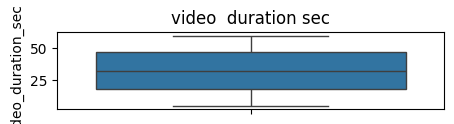

In [ ]:
# Visualizing Video Duration Distribution

plt.figure(figsize=(5,1))
plt.title('video  duration sec')
sns.boxplot(data['video_duration_sec'])


<Axes: title={'center': 'video duration sec'}, xlabel='video_duration_sec', ylabel='Count'>

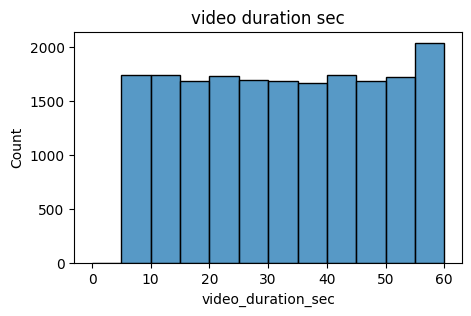

In [ ]:
# Histogram for Video Duration Distribution
plt.figure(figsize=(5,3))
plt.title('video duration sec')
sns.histplot(data['video_duration_sec'],bins=range(0,61,5))

<Axes: title={'center': 'video_view_count'}, ylabel='video_view_count'>

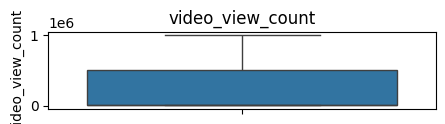

In [ ]:
# Visualizing Video View Count Distribution

plt.figure(figsize=(5,1))
plt.title('video_view_count')
sns.boxplot(data['video_view_count'])

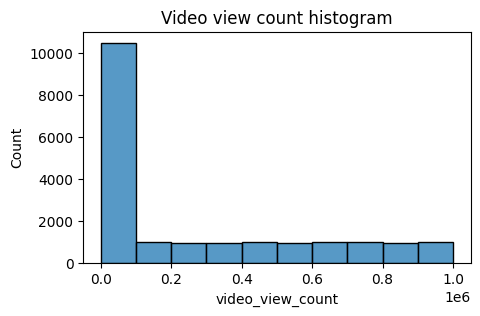

In [ ]:
#  Histogram for Video View Count Distribution

plt.figure(figsize=(5,3))
sns.histplot(data['video_view_count'], bins=range(0,(10**6+1),10**5))
plt.title('Video view count histogram');

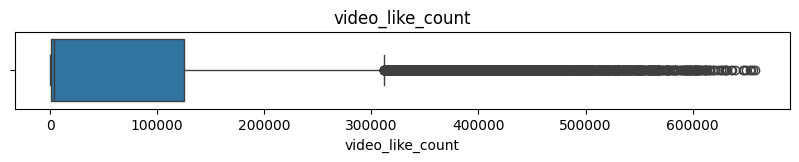

In [ ]:
# Visualizing Video Like Count Distribution

plt.figure(figsize=(10,1))
plt.title('video_like_count')
sns.boxplot(x=data['video_like_count']);


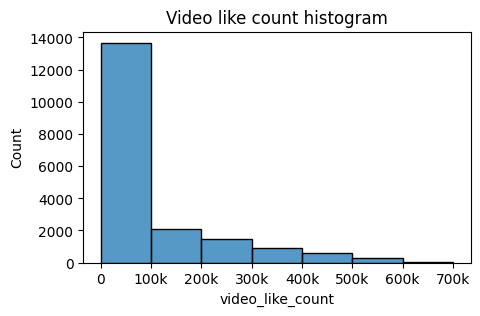

In [ ]:
# Histogram for Video Like Count Distribution

plt.figure(figsize=(5,3))
ax = sns.histplot(data['video_like_count'], bins=range(0,(7*10**5+1),10**5))
labels = [0] + [str(i) + 'k' for i in range(100, 701, 100)]
ax.set_xticks(range(0,7*10**5+1,10**5))
ax.set_xticklabels(labels)
plt.title('Video like count histogram');

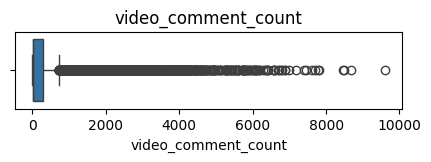

In [ ]:
# Visualizing Video Comment Count Distribution
plt.figure(figsize=(5,1))
plt.title('video_comment_count')
sns.boxplot(x=data['video_comment_count']);


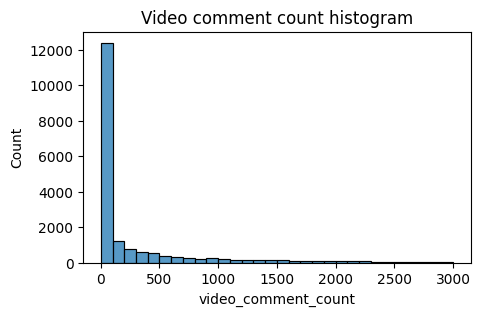

In [ ]:
# Histogram for Video Comment Count Distribution
plt.figure(figsize=(5,3))
sns.histplot(data['video_comment_count'], bins=range(0,(3001),100))
plt.title('Video comment count histogram');

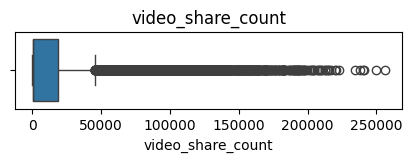

In [ ]:
# Visualizing Video Share Count Distribution
plt.figure(figsize=(5,1))
plt.title('video_share_count')
sns.boxplot(x=data['video_share_count']);

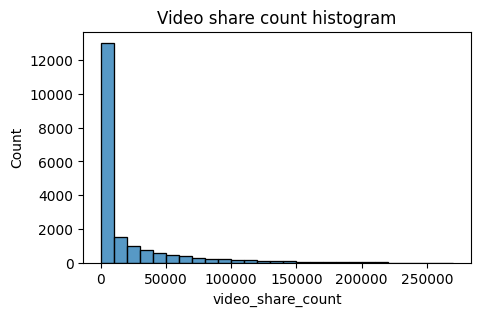

In [ ]:
# Histogram for Video Share Count Distribution
plt.figure(figsize=(5,3))
sns.histplot(data['video_share_count'], bins=range(0,(270001),10000))
plt.title('Video share count histogram');

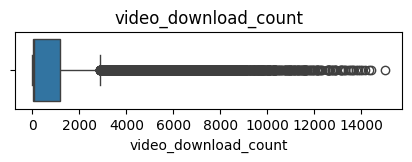

In [ ]:
# Visualizing Video Download Count Distribution
plt.figure(figsize=(5,1))
plt.title('video_download_count')
sns.boxplot(x=data['video_download_count']);

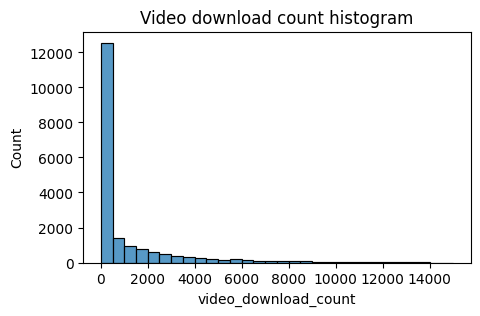

In [ ]:
# Histogram for Video Download Count Distribution

plt.figure(figsize=(5,3))
sns.histplot(data['video_download_count'], bins=range(0,(15001),500))
plt.title('Video download count histogram');

Text(0.5, 1.0, 'Claims by verification status histogram')

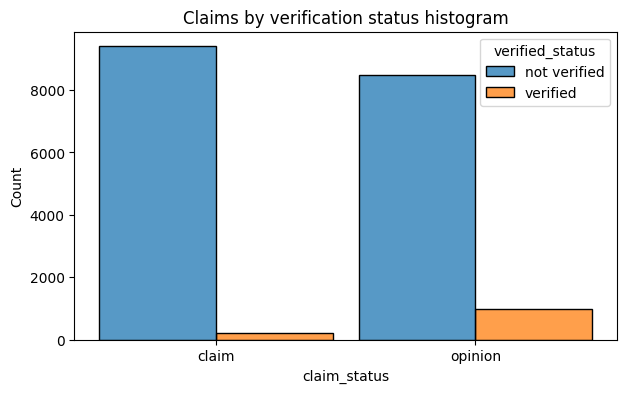

In [ ]:
# Histogram for Claim by Verification status
plt.figure(figsize=(7,4))
sns.histplot(data=data,
             x='claim_status',
             hue='verified_status',
             multiple='dodge',
             shrink=0.9)
plt.title('Claims by verification status histogram')

 There are far fewer verified users than unverified users, but if a user is
verified, they are much more likely to post opinions

Text(0.5, 1.0, 'Claims by author ban status')

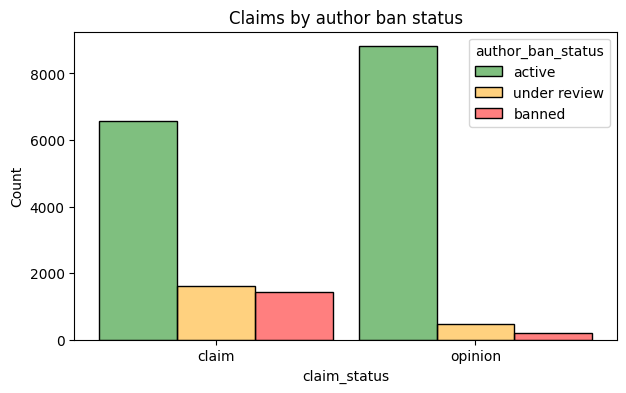

In [ ]:
# Histogram for Claim by Author Ban Status
plt.figure(figsize=(7,4))
sns.histplot(data=data,
            x='claim_status',
            hue='author_ban_status',
            hue_order=['active','under review','banned'],
            palette ={'active':'green', 'under review':'orange', 'banned':'red'},
            multiple = 'dodge',
            shrink=0.9,
            alpha=0.5
           )
plt.title('Claims by author ban status')

 For both claims and opinions, there are many more active authors than
banned authors or authors under review; however, the proportion of active authors is far greater
for opinion videos than for claim videos. Again, it seems that authors who post claim videos are
more likely to come under review and/or get banned

/tmp/ipykernel_2214/322870278.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ban_status_counts['author_ban_status'],


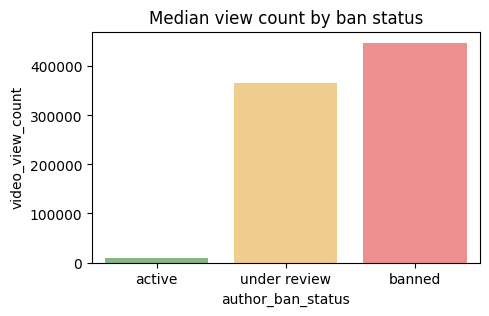

In [ ]:
# Bar plot for Median View Count by Ban Status
ban_status_counts = data.groupby(['author_ban_status']).median(
    numeric_only=True).reset_index()

fig = plt.figure(figsize=(5,3))
sns.barplot(x=ban_status_counts['author_ban_status'],
            y=ban_status_counts['video_view_count'],
            order=['active', 'under review', 'banned'],
            palette={'active':'green', 'under review':'orange', 'banned':'red'},
            alpha=0.5)
plt.title('Median view count by ban status');


 The median view counts for non-active authors are many times greater than
the median view count for active authors. Since you know that non-active authors are more likely
to post claims, and that videos by non-active authors get far more views on aggregate than videos
by active authors, then video_view_count might be a good indicator of claim status.

/tmp/ipykernel_2214/4080209847.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=claim_status_median['claim_status'],


<Axes: xlabel='claim_status', ylabel='video_view_count'>

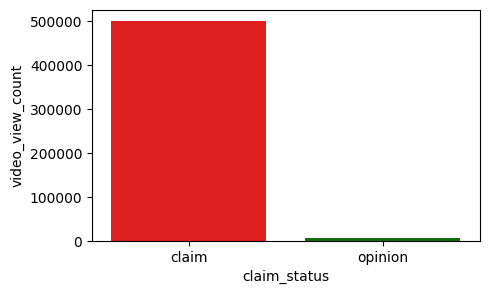

In [ ]:
# Finding the  Median View Count for Claim Status using Bar plot
### YOUR CODE HERE ###
plt.figure(figsize=(5,3))
claim_status_median= data.groupby('claim_status').median(numeric_only=True).reset_index()
sns.barplot(x=claim_status_median['claim_status'],
            y=claim_status_median['video_view_count'],
            palette={'claim':'red', 'opinion': 'green'}
            )

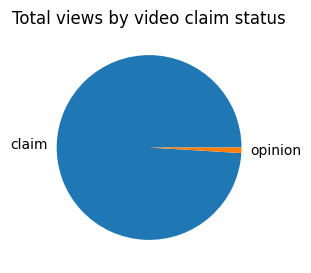

In [ ]:
# Pie chart for Total Views by Video Claim Status
fig = plt.figure(figsize=(3,3))
plt.pie(data.groupby('claim_status')['video_view_count'].sum(), labels=['claim', 'opinion'])
plt.title('Total views by video claim status');

 The overall view count is dominated by claim videos even though there are
roughly the same number of each video in the dataset

In [ ]:
# Outliers Determined

count_cols=['video_view_count','video_like_count', 'video_share_count',
            'video_download_count', 'video_comment_count']

for col in count_cols:
  q1=data[col].quantile(0.25)
  q3=data[col].quantile(0.75)
  iqr= q3-q1
  med= data[col].median()
  outer_threshold= med+1.5*iqr
  outer_count = (data[col] > outer_threshold).sum()
  print(f'Number of outliers, {col}:', outer_count)




Number of outliers, video_view_count: 2343
Number of outliers, video_like_count: 3468
Number of outliers, video_share_count: 3732
Number of outliers, video_download_count: 3733
Number of outliers, video_comment_count: 3882


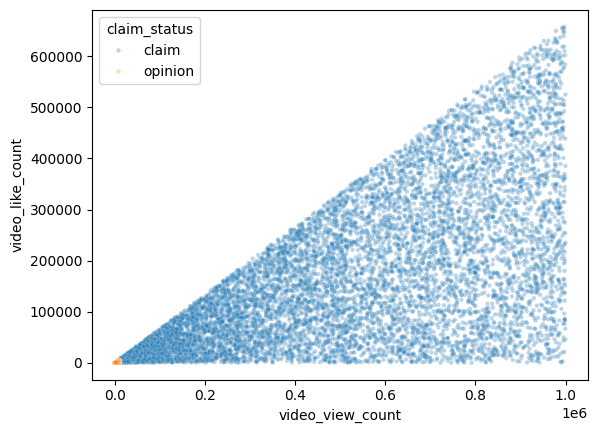

In [ ]:
# A Scatterplot of `video_view_count` versus `video_like_count` according to 'claim_status'

sns.scatterplot(x=data["video_view_count"], y=data["video_like_count"],
                hue=data["claim_status"], s=10, alpha=.3)
plt.show()

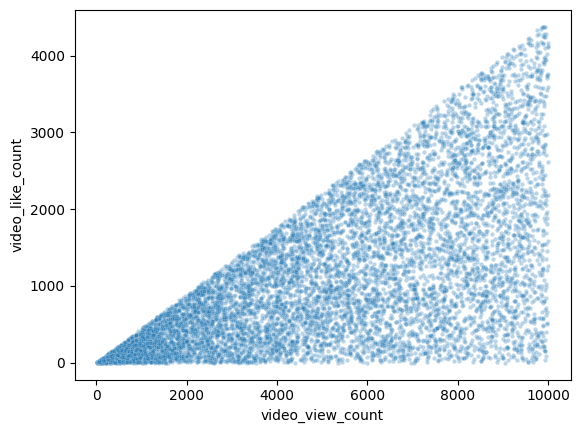

In [ ]:
# A Scatterplot of ``video_view_count` versus `video_like_count` for opinions only

opinion = data[data['claim_status']=='opinion']
sns.scatterplot(x=opinion["video_view_count"], y=opinion["video_like_count"],
                 s=10, alpha=.3)
plt.show()


###Summary Of EDA

A key component of this project’s exploratory data analysis involves
visualizing the data. As illustrated in the above histograms, it is
clear that the vast majority of videos are grouped at the bottom of
the range of values for three variables that showcase TikTok users
(video viewers’) engagement with the videos included in this
dataset - video_view, video_like,video_comment.The data showed a skewed right distribution.

Class imbalance was studied for claim_status- Both claim and opinion videos are nearly equal in number in the dataset
Also, there were null values which we removed for better experimentation with modelling.

### Pvalue

We find the pvalue to understand if the data is statistically significant. With a significance level at 0.05 (5%)

In [ ]:
# The mean `video_view_count` for each group in `verified_status`

df=data.groupby('verified_status')['video_view_count'].mean().reset_index()

We examine the mean
values of video_view_count for each group of
verified_status in the sample data. The findings
showed that unverified accounts have a mean of
265,663 views vs. 91,439 views for verified accounts.

In [ ]:
# Conducted a two-sample t-test to compare means

not_verified= data[data['verified_status']== 'not verified']['video_view_count']
verified= data[data['verified_status']=='verified']['video_view_count']

stats.ttest_ind(a=not_verified,b=verified,equal_var=False)

TtestResult(statistic=np.float64(25.499441780633777), pvalue=np.float64(2.6088823687177823e-120), df=np.float64(1571.163074387424))

With a pvalue of 2.6088823687177823e-120, the data is statistically significant
We conduct a two-sample hypothesis
test. Aligned with preliminary findings from the mean
values, this statistical analysis shows that any
observed difference in the sample data is due to an
actual difference in the corresponding population
means

A regression model for verified_status can help
analyze user behavior in this group of verified
users. Then, this context can be used to
consider results from a claim classification
model that will be created afterwards.

###Logistic Regression Analysis on Verified status

In [ ]:
# Class Balance for Verified Status Checked

data["verified_status"].value_counts(normalize=True)

,proportion
verified_status,
not verified,0.93712
verified,0.06288


In [ ]:
# Used resampling to create class balance in the outcome variable

# Identified data points from majority and minority classes

data_majority = data[data["verified_status"] == "not verified"]
data_minority = data[data["verified_status"] == "verified"]

# Upsampled the minority class (which is "verified")

data_minority_upsampled = resample(data_minority,
                                 replace=True,                 # to sample with replacement
                                 n_samples=len(data_majority), # to match majority class
                                 random_state=0)               # to create reproducible results

# Combined majority class with upsampled minority class

data_upsampled = pd.concat([data_majority, data_minority_upsampled]).reset_index(drop=True)
# Displayed  new class counts

data_upsampled["verified_status"].value_counts()

,count
verified_status,
not verified,17884
verified,17884


Feature Engineering

In [ ]:
#To get the average `video_transcription_text` length for claims and the average `video_transcription_text` length for opinions

# Created a helper column
data_upsampled['text_length'] = data_upsampled['video_transcription_text'].str.len()

# Group and mean
data_upsampled.groupby('verified_status')['text_length'].mean()

,text_length
verified_status,
not verified,89.401141
verified,84.569559


In [ ]:
# Displayed first few rows of dataframe after adding new column
data_upsampled.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


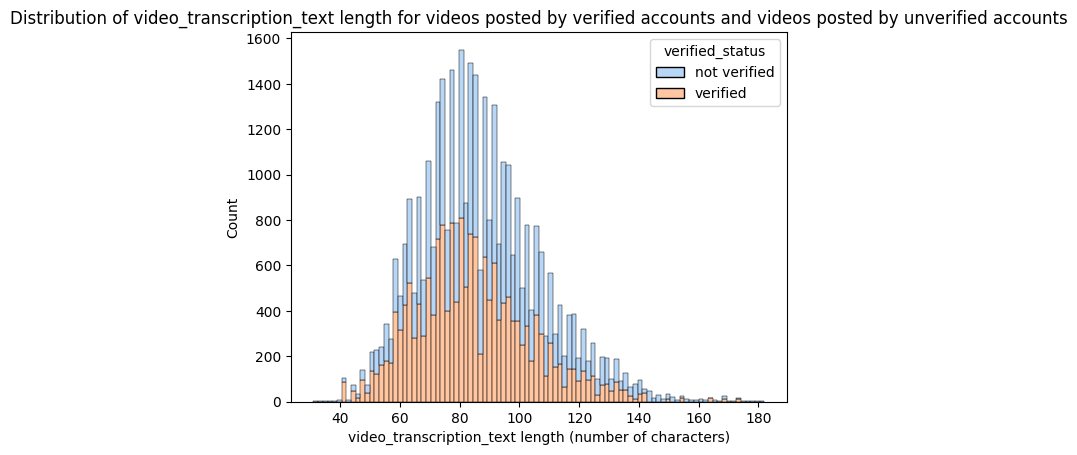

In [ ]:
# Visualizing the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts
# Created two histograms in one plot

sns.histplot(data=data_upsampled, stat="count", multiple="stack", x="text_length", kde=False, palette="pastel",
             hue="verified_status", element="bars", legend=True)
plt.title("Seaborn Stacked Histogram")
plt.xlabel("video_transcription_text length (number of characters)")
plt.ylabel("Count")
plt.title("Distribution of video_transcription_text length for videos posted by verified accounts and videos posted by unverified accounts")
plt.show()

In [ ]:
# Coded a correlation matrix to help determine most correlated variables

data_upsampled.corr(numeric_only=True)

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
#,1.000000,-0.000853,-0.011729,-0.697007,-0.626385,-0.504015,-0.487096,-0.608773,-0.193677
video_id,-0.000853,1.000000,0.011859,0.002554,0.005993,0.010515,0.008753,0.012674,-0.007083
video_duration_sec,-0.011729,0.011859,1.000000,0.013589,0.004494,0.002206,0.003989,-0.001086,-0.002981
video_view_count,-0.697007,0.002554,0.013589,1.000000,0.856937,0.711313,0.690048,0.748361,0.244693
video_like_count,-0.626385,0.005993,0.004494,0.856937,1.000000,0.832146,0.805543,0.818032,0.216693
video_share_count,-0.504015,0.010515,0.002206,0.711313,0.832146,1.000000,0.710117,0.671335,0.171651
video_download_count,-0.487096,0.008753,0.003989,0.690048,0.805543,0.710117,1.000000,0.793668,0.173396
video_comment_count,-0.608773,0.012674,-0.001086,0.748361,0.818032,0.671335,0.793668,1.000000,0.217661
text_length,-0.193677,-0.007083,-0.002981,0.244693,0.216693,0.171651,0.173396,0.217661,1.000000


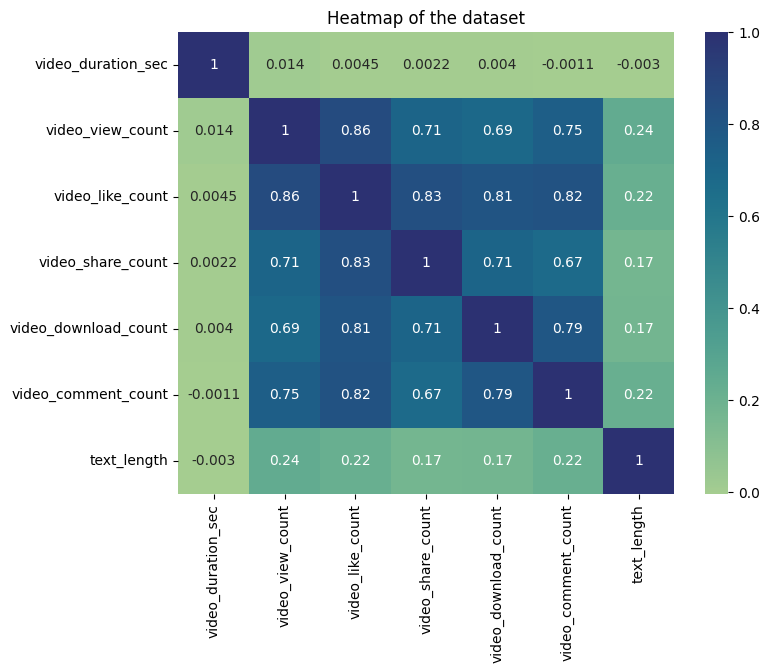

In [ ]:
# Created a heatmap to visualize how correlated variables are


plt.figure(figsize=(8, 6))
sns.heatmap(
    data_upsampled[["video_duration_sec", "claim_status", "author_ban_status", "video_view_count",
                    "video_like_count", "video_share_count", "video_download_count", "video_comment_count", "text_length"]]
    .corr(numeric_only=True),
    annot=True,
    cmap="crest")
plt.title("Heatmap of the dataset")
plt.show()

We drop the video_like_count since it is correlated with other variables

### Regression Modeling

In [ ]:
# Outcome Variable

y = data_upsampled["verified_status"]


In [ ]:
# Select features

X = data_upsampled[["video_duration_sec", "claim_status", "author_ban_status", "video_view_count", "video_share_count", "video_download_count", "video_comment_count"]]


# Check by displaying the first few rows of features dataframe

X.head()

,video_duration_sec,claim_status,author_ban_status,video_view_count,video_share_count,video_download_count,video_comment_count
0,59,claim,under review,343296.0,241.0,1.0,0.0
1,32,claim,active,140877.0,19034.0,1161.0,684.0
2,31,claim,active,902185.0,2858.0,833.0,329.0
3,25,claim,active,437506.0,34812.0,1234.0,584.0
4,19,claim,active,56167.0,4110.0,547.0,152.0


In [ ]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [ ]:
# Shape of each training and testing set

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((26826, 7), (8942, 7), (26826,), (8942,))

In [ ]:
# Check data types

X_train.dtypes

,0
video_duration_sec,int64
claim_status,object
author_ban_status,object
video_view_count,float64
video_share_count,float64
video_download_count,float64
video_comment_count,float64


In [ ]:
# Unique values in `claim_status`

X_train["claim_status"].unique()


array(['opinion', 'claim'], dtype=object)

In [ ]:
# Unique values in `author_ban_status`

X_train["author_ban_status"].unique()

array(['active', 'under review', 'banned'], dtype=object)

In [ ]:
# Select the training features that needs to be encoded

X_train_to_encode = X_train[["claim_status", "author_ban_status"]]

# Display first few rows

X_train_to_encode.head()

,claim_status,author_ban_status
33058,opinion,active
20491,opinion,active
25583,opinion,active
18474,opinion,active
27312,opinion,active


In [ ]:
# An encoder for one-hot encoding the categorical features

X_encoder = OneHotEncoder(drop='first', sparse_output=False)

In [ ]:
# Fit and transform the training features using the encoder

X_train_encoded = X_encoder.fit_transform(X_train_to_encode)

In [ ]:
# Feature names from encoder

X_encoder.get_feature_names_out()

array(['claim_status_opinion', 'author_ban_status_banned',
       'author_ban_status_under review'], dtype=object)

In [ ]:
# Checking the first few rows of encoded training features

X_train_encoded

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [ ]:
# Encoded training features  into a dataframe

X_train_encoded_df = pd.DataFrame(data=X_train_encoded, columns=X_encoder.get_feature_names_out())

# Checking  first few rows

X_train_encoded_df.head()

,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


In [ ]:
# Checking  first few rows of `X_train` with `claim_status` and `author_ban_status` columns dropped (since these features are being transformed to numeric)

X_train.drop(columns=["claim_status", "author_ban_status"]).head()

,video_duration_sec,video_view_count,video_share_count,video_download_count,video_comment_count
33058,33,2252.0,23.0,4.0,0.0
20491,52,6664.0,550.0,53.0,2.0
25583,37,6327.0,257.0,3.0,0.0
18474,57,1702.0,28.0,0.0,0.0
27312,21,3842.0,101.0,1.0,0.0


In [ ]:
# Concatenate `X_train` and `X_train_encoded_df` to form the final dataframe for training data (`X_train_final`)

X_train_final = pd.concat([X_train.drop(columns=["claim_status", "author_ban_status"]).reset_index(drop=True), X_train_encoded_df], axis=1)
# Checking the first few rows

X_train_final.head()

,video_duration_sec,video_view_count,video_share_count,video_download_count,video_comment_count,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,33,2252.0,23.0,4.0,0.0,1.0,0.0,0.0
1,52,6664.0,550.0,53.0,2.0,1.0,0.0,0.0
2,37,6327.0,257.0,3.0,0.0,1.0,0.0,0.0
3,57,1702.0,28.0,0.0,0.0,1.0,0.0,0.0
4,21,3842.0,101.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
# Check data type of outcome variable

y_train.dtype

dtype('O')

In [ ]:
# Unique values of outcome variable

y_train.unique()

array(['verified', 'not verified'], dtype=object)

In [ ]:
# An encoder for one-hot encoding the categorical outcome variable

y_encoder = OneHotEncoder(drop='first', sparse_output=False)

In [ ]:
# Encode the training outcome variable

y_train_final = y_encoder.fit_transform(y_train.values.reshape(-1, 1)).ravel()
# Checking the encoded training outcome variable

y_train_final

array([1., 1., 1., ..., 1., 1., 0.])

###Construstung Logistic Regression Model

In [ ]:
# Construct a logistic regression model and fit it to the training set


log_clf = LogisticRegression(random_state=0, max_iter=800).fit(X_train_final, y_train_final)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Selecting the testing features that needs to be encoded

X_test_to_encode = X_test[["claim_status", "author_ban_status"]]


# checking the first few rows

X_test_to_encode.head()

,claim_status,author_ban_status
21061,opinion,active
31748,opinion,active
20197,claim,active
5727,claim,active
11607,opinion,active


In [ ]:
# Transforming the testing features using the encoder

X_test_encoded = X_encoder.transform(X_test_to_encode)

# Checking the first few rows of encoded testing features

X_test_encoded

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [ ]:
# Encoded testing features in a dataframe


X_test_encoded_df = pd.DataFrame(data=X_test_encoded, columns=X_encoder.get_feature_names_out())
# Checking first few rows

X_test_encoded_df.head()

,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,1.0,0.0,0.0


In [ ]:

X_test.drop(columns=["claim_status", "author_ban_status"]).head()

,video_duration_sec,video_view_count,video_share_count,video_download_count,video_comment_count
21061,41,2118.0,57.0,5.0,2.0
31748,27,5701.0,157.0,1.0,0.0
20197,31,449767.0,75385.0,5956.0,728.5
5727,19,792813.0,56597.0,5146.0,728.5
11607,54,2044.0,68.0,19.0,2.0


In [ ]:
# Concatenating `X_test` and `X_test_encoded_df` to form the final dataframe for training data (`X_test_final`)

X_test_final = pd.concat([X_test.drop(columns=["claim_status", "author_ban_status"]).reset_index(drop=True), X_test_encoded_df], axis=1)

# Checking the first few rows

X_test_final.head()

,video_duration_sec,video_view_count,video_share_count,video_download_count,video_comment_count,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,41,2118.0,57.0,5.0,2.0,1.0,0.0,0.0
1,27,5701.0,157.0,1.0,0.0,1.0,0.0,0.0
2,31,449767.0,75385.0,5956.0,728.5,0.0,0.0,0.0
3,19,792813.0,56597.0,5146.0,728.5,0.0,0.0,0.0
4,54,2044.0,68.0,19.0,2.0,1.0,0.0,0.0


In [ ]:
# Using the logistic regression model to get predictions on the encoded testing set

y_pred = log_clf.predict(X_test_final)

In [ ]:
# Displaying the predictions on the encoded testing set

y_pred

array([1., 1., 0., ..., 1., 0., 1.])

In [ ]:
# Displaying the true labels of the testing set

y_test

,verified_status
21061,verified
31748,verified
20197,verified
5727,not verified
11607,not verified
...,...
14756,not verified
26564,verified
14800,not verified
35705,verified


In [ ]:
# Encode the testing outcome variable

y_test_final = y_encoder.transform(y_test.values.reshape(-1, 1)).ravel()

# Checking the encoded testing outcome variable
y_test_final

array([1., 1., 1., ..., 0., 1., 1.])

In [ ]:
# Shape of each training and testing set

X_train_final.shape, y_train_final.shape, X_test_final.shape, y_test_final.shape

((26826, 8), (26826,), (8942, 8), (8942,))

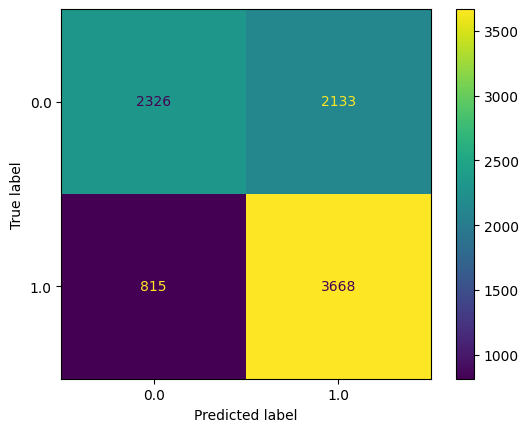

In [ ]:
# Compute confusion matrix

log_cm = confusion_matrix(y_test_final, y_pred, labels=log_clf.classes_)
# Create display of confusion matrix

log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=log_clf.classes_)
# Plot confusion matrix

log_disp.plot()
# Display plot

plt.show()

In [ ]:
# Classification report of the model

target_labels = ["verified", "not verified"]
print(classification_report(y_test_final, y_pred, target_names=target_labels))

              precision    recall  f1-score   support

    verified       0.74      0.52      0.61      4459
not verified       0.63      0.82      0.71      4483

    accuracy                           0.67      8942
   macro avg       0.69      0.67      0.66      8942
weighted avg       0.69      0.67      0.66      8942



In [ ]:
# Feature names from the model and the model coefficients (which represent log-odds ratios)


pd.DataFrame(data={"Feature Name":log_clf.feature_names_in_, "Model Coefficient":log_clf.coef_[0]})

,Feature Name,Model Coefficient
0,video_duration_sec,-2.453584e-03
1,video_view_count,-1.688341e-07
2,video_share_count,4.826042e-06
3,video_download_count,-8.108640e-05
4,video_comment_count,4.482967e-04
5,claim_status_opinion,1.702606e+00
6,author_ban_status_banned,-4.484377e-01
7,author_ban_status_under review,-9.868367e-02


The variable of verified_status was selected for
this regression model because of the
relationship seen between the verified account
type and the video content. A logistic
regression model was selected because of the
data type and distribution.

Earlier, we observed that if a user is verified, they are
much more likely to post opinions. Since the end goal is to classify claims and opinions, it’s
important to build a model that shows how to predict the behavior of the account type (verified)
that tend to post more opinions. So, in this part of the project, we built a logistic
regression model that predicts verified_status. From the model coefficients, its clear that verified accounts likely post more opinions than claims, and also verified accounts are much less likely to be under banned status.

###Random Forest Model

In [ ]:
# Create `text_length` column
data['text_length'] = data['video_transcription_text'].str.len()
data.head()

/tmp/ipykernel_5419/3450924538.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['text_length'] = data['video_transcription_text'].str.len()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


In [ ]:
data[['claim_status', 'text_length']].groupby('claim_status').mean()

,text_length
claim_status,
claim,95.376978
opinion,82.722562


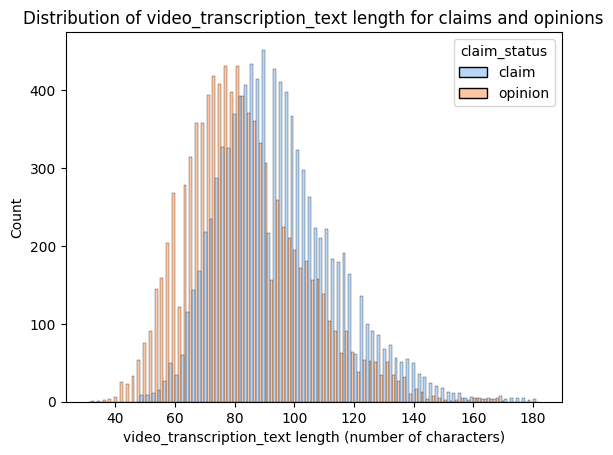

In [ ]:
# Visualize the distribution of `text_length` for claims and opinions
# Create two histograms in one plot

sns.histplot(data=data, stat="count", multiple="dodge", x="text_length",
             kde=False, palette="pastel", hue="claim_status",
             element="bars", legend=True)
plt.xlabel("video_transcription_text length (number of characters)")
plt.ylabel("Count")
plt.title("Distribution of video_transcription_text length for claims and opinions")
plt.show()

In [ ]:
Xt = data.copy()
# Drop unnecessary columns
Xt = Xt.drop(['#', 'video_id'], axis=1)
# Encode target variable
Xt['claim_status'] = Xt['claim_status'].replace({'opinion': 0, 'claim': 1})
# Dummy encode remaining categorical values
Xt = pd.get_dummies(Xt,
                   columns=['verified_status', 'author_ban_status'],
                   drop_first=True)
Xt.head()

/tmp/ipykernel_5419/2696266934.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Xt['claim_status'] = Xt['claim_status'].replace({'opinion': 0, 'claim': 1})


,claim_status,video_duration_sec,video_transcription_text,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,1,59,someone shared with me that drone deliveries a...,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,1,32,someone shared with me that there are more mic...,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,1,31,someone shared with me that american industria...,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,1,25,someone shared with me that the metro of st. p...,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,1,19,someone shared with me that the number of busi...,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


In [ ]:
# Isolate target variable
yt = Xt['claim_status']

In [ ]:
# Isolate features
Xt = Xt.drop(['claim_status'], axis=1)

# Display first few rows of features dataframe
Xt.head()

,video_duration_sec,video_transcription_text,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,59,someone shared with me that drone deliveries a...,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,32,someone shared with me that there are more mic...,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,31,someone shared with me that american industria...,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,25,someone shared with me that the metro of st. p...,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,19,someone shared with me that the number of busi...,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


In [ ]:
# Split the data into training and testing sets
X_tr, X_test_tree, y_tr, y_test_tree = train_test_split(Xt, yt, test_size=0.2, random_state=0)

In [ ]:
# Split the training data into training and validation sets
X_train_tree, X_val, y_train_tree, y_val = train_test_split(X_tr, y_tr, test_size=0.25, random_state=0)

In [ ]:
# Get shape of each training, validation, and testing set
X_train_tree.shape, X_val.shape, X_test_tree.shape, y_train_tree.shape, y_val.shape, y_test_tree.shape

((11450, 11), (3817, 11), (3817, 11), (11450,), (3817,), (3817,))

###Tokenize video transcription

In [ ]:
# Set up a `CountVectorizer` object, which converts a collection of text to a matrix of token counts
count_vec = CountVectorizer(ngram_range=(2, 3),
                            max_features=15,
                            stop_words='english')
#count_vec
# Since we pickled, we comment out the count_vec

CountVectorizer(max_features=15, ngram_range=(2, 3), stop_words='english')

In [ ]:
# Extract numerical features from `video_transcription_text` in the training set
count_data = count_vec.fit_transform(X_train_tree['video_transcription_text']).toarray()
count_data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 1, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
# Place the numerical representation of `video_transcription_text` from training set into a dataframe
count_df = pd.DataFrame(data=count_data, columns=count_vec.get_feature_names_out())

# Display first few rows
count_df.head()

,colleague discovered,colleague learned,colleague read,discovered news,discussion board,friend learned,friend read,internet forum,learned media,media claim,news claim,point view,read media,social media,willing wager
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Concatenate `X_train` and `count_df` to form the final dataframe for training data (`X_train_final`)

X_train_tree_final = pd.concat([X_train_tree.drop(columns=['video_transcription_text']).reset_index(drop=True), count_df], axis=1)

# Display first few rows
X_train_tree_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review,...,friend learned,friend read,internet forum,learned media,media claim,news claim,point view,read media,social media,willing wager
0,51,2487.0,310.0,20.0,1.0,0.0,134,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,43,118512.0,3543.0,374.0,70.0,29.0,97,False,True,False,...,0,1,0,0,0,0,0,0,0,0
2,22,105902.0,1885.0,229.0,39.0,9.0,76,False,False,True,...,0,1,0,0,0,0,0,0,0,0
3,17,9245.0,1670.0,440.0,13.0,4.0,58,False,False,False,...,0,0,0,0,0,0,0,0,0,0
4,18,3791.0,660.0,63.0,9.0,1.0,57,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Extract numerical features from `video_transcription_text` in the Validating set
validation_count_data = count_vec.transform(X_val['video_transcription_text']).toarray()
validation_count_data

array([[0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
# Place the numerical representation of `video_transcription_text` from validation set into a dataframe
validation_count_df = pd.DataFrame(data=validation_count_data, columns=count_vec.get_feature_names_out())
validation_count_df.head()

,colleague discovered,colleague learned,colleague read,discovered news,discussion board,friend learned,friend read,internet forum,learned media,media claim,news claim,point view,read media,social media,willing wager
0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0


In [ ]:
# Concatenate `X_val` and `validation_count_df` to form the final dataframe for training data (`X_val_final`)

X_val_final = pd.concat([X_val.drop(columns=['video_transcription_text']).reset_index(drop=True), validation_count_df], axis=1)

# Display first few rows
X_val_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review,...,friend learned,friend read,internet forum,learned media,media claim,news claim,point view,read media,social media,willing wager
0,11,578891.0,379596.0,14612.0,6591.0,44.0,72,False,False,True,...,0,0,0,0,0,0,0,1,0,0
1,24,6255.0,1709.0,311.0,13.0,1.0,96,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,35,410356.0,249714.0,26235.0,2060.0,1252.0,88,False,False,False,...,0,1,0,0,0,0,0,1,0,0
3,58,406911.0,25986.0,1230.0,564.0,248.0,83,False,False,False,...,0,0,0,0,0,0,0,0,0,0
4,47,972573.0,138167.0,25320.0,3331.0,968.0,104,False,False,True,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
# Extract numerical features from `video_transcription_text` in the testing set
test_count_data = count_vec.transform(X_test_tree['video_transcription_text']).toarray()

# Place the numerical representation of `video_transcription_text` from test set into a dataframe
test_count_df = pd.DataFrame(data=test_count_data, columns=count_vec.get_feature_names_out())

# Concatenate `X_val` and `validation_count_df` to form the final dataframe for training data (`X_val_final`)
X_test_tree_final = pd.concat([X_test_tree.drop(columns=['video_transcription_text']
                                      ).reset_index(drop=True), test_count_df], axis=1)
X_test_tree_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review,...,friend learned,friend read,internet forum,learned media,media claim,news claim,point view,read media,social media,willing wager
0,54,692084.0,135956.0,16591.0,622.0,312.0,107,False,False,False,...,0,0,0,1,1,0,0,0,0,0
1,37,5164.0,1858.0,36.0,17.0,1.0,69,True,False,True,...,0,0,0,0,0,0,0,0,0,0
2,39,801951.0,344163.0,57608.0,8578.0,2942.0,90,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,44,6429.0,2314.0,847.0,17.0,5.0,76,False,False,False,...,0,0,0,0,0,0,0,0,0,0
4,26,555780.0,106863.0,15348.0,252.0,91.0,72,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [ ]:


# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=0)

# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [5, 7, None],
             'max_features': [0.3, 0.6],
            #  'max_features': 'auto'
             'max_samples': [0.7],
             'min_samples_leaf': [1,2],
             'min_samples_split': [2,3],
             'n_estimators': [75,100,200],
             }

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='recall')

In [ ]:
### THIS WILL TAKE A LONG TIME TO RUN
%%time
# rf_cv.fit(X_train_tree_final, y_train_tree)
# Since we pickled the model we comment out this line

CPU times: user 9min 37s, sys: 581 ms, total: 9min 38s
Wall time: 9min 42s


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [5, 7, None], 'max_features': [0.3, 0.6],
                         'max_samples': [0.7], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [75, 100, 200]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [ ]:
import pickle

# This saves your specific text tokenizer configuration
with open('tiktok_vectorizer.pkl', 'wb') as file:
    pickle.dump(count_vec, file)

print("Perfect! Your CountVectorizer is safely pickled and locked down.")

Perfect! Your CountVectorizer is safely pickled and locked down.


In [ ]:
# Examine best recall score
rf_cv.best_score_

np.float64(0.9948228253467271)

In [ ]:
import pickle

# This grabs your trained Random Forest estimator
rf_backup_model = rf_cv.best_estimator_

# This saves it with a crystal-clear filename
with open('tiktok_random_forest_backup.pkl', 'wb') as file:
    pickle.dump(rf_backup_model, file)

print("Backup complete! Your Random Forest model is safely sealed.")

Backup complete! Your Random Forest model is safely sealed.


In [ ]:
# Examine best parameters
rf_cv.best_params_

{'max_depth': None,
 'max_features': 0.6,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

We check the precision score to make sure the model isn't labeling everything as claims. We can do this by using the cv_results_ attribute of the fit GridSearchCV object, which returns a numpy array that can be converted to a pandas dataframe. Then, examine the mean_test_precision column of this dataframe at the index containing the results from the best model. This index can be accessed by using the best_index_ attribute of the fit GridSearchCV object.

In [ ]:
# Access the GridSearch results and convert it to a pandas df
rf_results_df = pd.DataFrame(rf_cv.cv_results_)

# Examine the GridSearch results df at column `mean_test_precision` in the best index
rf_results_df['mean_test_precision'][rf_cv.best_index_]

np.float64(0.9994806638131711)

###Modeling using XGBoost

In [ ]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=0)

# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [4,8,12],
             'min_child_weight': [3, 5],
             'learning_rate': [0.01, 0.1],
             'n_estimators': [300, 500]
             }

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='recall')

In [ ]:
### THIS WILL TAKE A LONG TIME TO RUN
%%time
# xgb_cv.fit(X_train_tree_final, y_train_tree)

CPU times: user 2min 44s, sys: 1.82 s, total: 2min 45s
Wall time: 1min 35s


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [4, 8, 12],
                         'min_child_weight': [3, 5],
                         'n_estimators': [300, 500]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [ ]:
xgb_cv.best_score_

np.float64(0.9898176171763818)

In [ ]:
import pickle

# This extracts your trained, champion XGBoost estimator
xgb_backup_model = xgb_cv.best_estimator_

# This seals it into its own separate pickle file
with open('tiktok_xgboost_backup.pkl', 'wb') as file:
    pickle.dump(xgb_backup_model, file)

print("Awesome! The XGBoost model is safely pickled and locked down.")

Awesome! The XGBoost model is safely pickled and locked down.


In [ ]:
xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 4,
 'min_child_weight': 5,
 'n_estimators': 300}

In [ ]:
# Access the GridSearch results and convert it to a pandas df
xgb_results_df = pd.DataFrame(xgb_cv.cv_results_)

# Examine the GridSearch results df at column `mean_test_precision` in the best index
xgb_results_df['mean_test_precision'][xgb_cv.best_index_]

np.float64(0.9989540885869099)

XGBoost model also performs exceptionally well. Although both its precision and recall scores are very slightly lower than the random forest model's.

###Evaluate the models - Random forest and XGBoost

In [ ]:
# Use the random forest "best estimator" model to get predictions on the validation set
y_pred_tree= rf_cv.best_estimator_.predict(X_val_final)

In [ ]:
# Display the predictions on the validation set
y_pred_tree

array([1, 0, 1, ..., 1, 1, 1])

In [ ]:
# Display the true labels of the validation set
y_val

,claim_status
5846,1
12058,0
2975,1
8432,1
6863,1
...,...
6036,1
6544,1
2781,1
6426,1


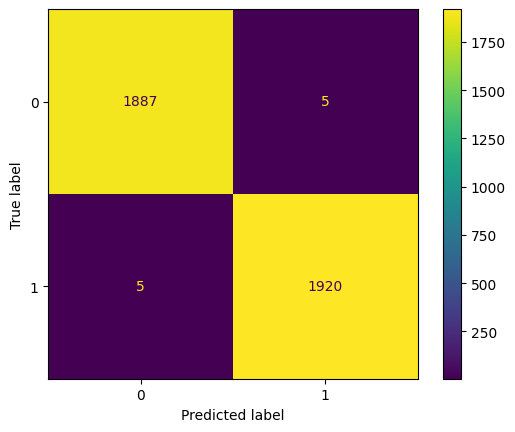

In [ ]:
# Create a confusion matrix to visualize the results of the classification model

# Compute values for confusion matrix
log_cm = confusion_matrix(y_val, y_pred_tree)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=None)

# Plot confusion matrix
log_disp.plot()

# Display plot
plt.show()

In [ ]:
# Create a classification report
# Create classification report for random forest model
target_labels = ['opinion', 'claim']
print(classification_report(y_val, y_pred_tree, target_names=target_labels))

              precision    recall  f1-score   support

     opinion       1.00      1.00      1.00      1892
       claim       1.00      1.00      1.00      1925

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817



The classification report above shows that the random forest model scores were perfect, but we know they weren't quite perfect. The confusion matrix indicates that there were 10 misclassifications—five false postives and five false negatives

Evaluation of XGBoost model

In [ ]:
# Use the best estimator to predict on the validation data
y_pred_tree = xgb_cv.best_estimator_.predict(X_val_final)

In [ ]:
y_pred_tree

array([1, 0, 1, ..., 1, 1, 1])

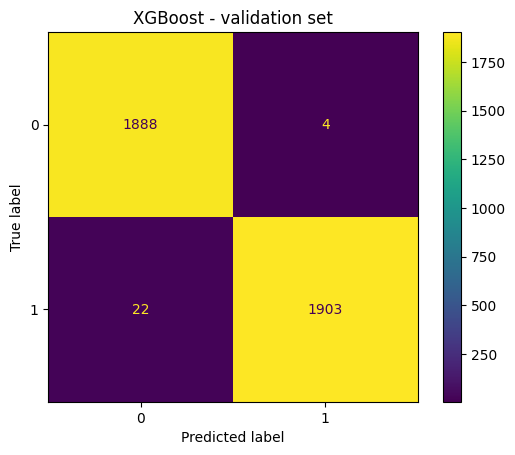

In [ ]:
# Compute values for confusion matrix
log_cm = confusion_matrix(y_val, y_pred_tree)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=None)

# Plot confusion matrix
log_disp.plot()

# Display plot
plt.title('XGBoost - validation set');
plt.show()


In [ ]:
# Create a classification report
target_labels = ['opinion', 'claim']
print(classification_report(y_val, y_pred_tree, target_names=target_labels))

              precision    recall  f1-score   support

     opinion       0.99      1.00      0.99      1892
       claim       1.00      0.99      0.99      1925

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



The results of the XGBoost model were also nearly perfect. However, its errors tended to be false negatives. Identifying claims was the priority, so it's important that the model be good at capturing all actual claim videos. The random forest model has a better scores, and is therefore the champion model.

###We chose random forest as champion model

###Using the Champion model to predict on test data

Both random forest and XGBoost model architectures resulted in nearly perfect models. Nonetheless, in this case random forest performed a little bit better, so it is the champion model.

In [ ]:
# Use champion model to predict on test data
y_pred_tree = rf_cv.best_estimator_.predict(X_test_tree_final)

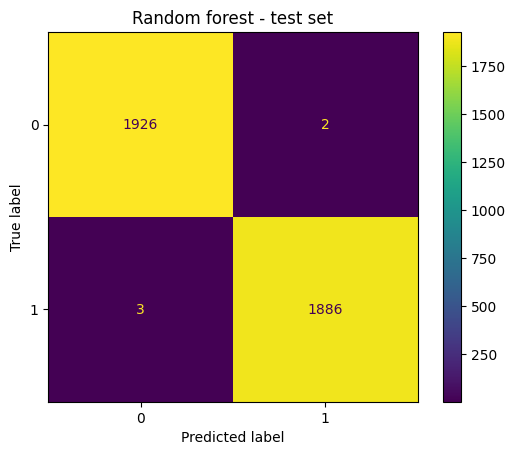

In [ ]:
# Compute values for confusion matrix
log_cm = confusion_matrix(y_test_tree, y_pred_tree)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=None)

# Plot confusion matrix
log_disp.plot()

# Display plot
plt.title('Random forest - test set');
plt.show()

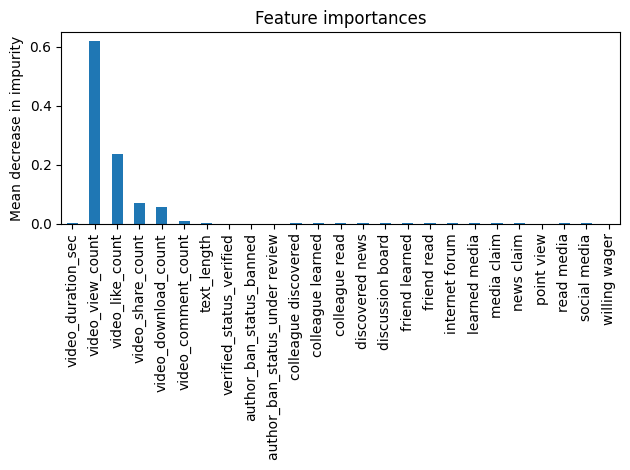

In [ ]:
importances = rf_cv.best_estimator_.feature_importances_
rf_importances = pd.Series(importances, index=X_test_tree_final.columns)

fig, ax = plt.subplots()
rf_importances.plot.bar(ax=ax)
ax.set_title('Feature importances')
ax.set_ylabel('Mean decrease in impurity')
fig.tight_layout()

The most predictive features all were related to engagement levels generated by the video. This is not unexpected, as analysis from prior EDA pointed to this conclusion.

##SUMMARY

We use Logistic Regression to model source credibility (verified_status), leveraging the algorithm's statistical interpretability to isolate how account-level metrics dictate verification. We then scale up to tree-based ensemble models (Random Forest and XGBoost) to model content risk (claim_status). This transition is necessary because classifying raw text data (processed via CountVectorizer) alongside high-velocity video engagement metrics introduces complex, non-linear relationships that decision-tree ensembles are uniquely optimized to capture."

The Random Forest model is the champion model that classifies whether a video is opinion or a claim